# Vision Transformer: por que una imagen vale 16x16 palabras

Este notebook explica de forma practica la idea central del articulo **An Image is Worth 16x16 Words** (ViT):

1. Tomar una imagen.
2. Dividirla en parches de tamano fijo (16x16).
3. Convertir cada parche en un token (embedding).
4. Enviar la secuencia de tokens a un Transformer.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

## 1) Cargar una imagen

Si existe una imagen local se usa esa; si no, se genera una imagen sintetica para que el notebook siempre funcione.

Imagen local: data/leonora.jpg


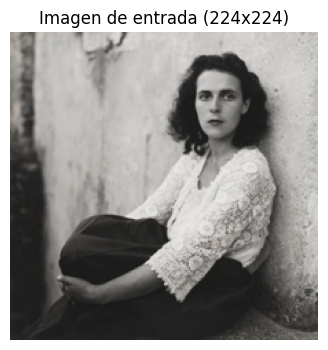

In [2]:
def cargar_imagen_o_generar(path='data/leonora.jpg', size=(224, 224)):
    if os.path.exists(path):
        img = Image.open(path).convert('RGB').resize(size)
        fuente = f'Imagen local: {path}'
    else:
        h, w = size
        y = np.linspace(0, 1, h)[:, None]
        x = np.linspace(0, 1, w)[None, :]

        r = (x * 255).astype(np.uint8)
        g = (y * 255).astype(np.uint8)
        b = (((1 - x) * (1 - y)) * 255).astype(np.uint8)

        r = np.repeat(r, h, axis=0)
        g = np.repeat(g, w, axis=1)

        arr = np.stack([r, g, b], axis=-1)

        arr[70:150, 70:150, :] = [255, 220, 30]
        arr[90:130, 90:130, :] = [40, 40, 240]

        img = Image.fromarray(arr)
        fuente = 'Imagen sintetica (fallback)'

    return img, fuente

img, fuente = cargar_imagen_o_generar()
print(fuente)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Imagen de entrada (224x224)')
plt.axis('off')
plt.show()

## 2) Idea del paper en una formula

Si la imagen es de tamano $H \times W$ y cada parche es de tamano $P \times P$, el numero de parches es:

$$
N = \frac{H}{P} \times \frac{W}{P}
$$

Con ViT-Base: $H=W=224$ y $P=16$:

$$
N = 14 \times 14 = 196
$$

Cada parche RGB tiene forma $16 \times 16 \times 3 = 768$ valores.

In [3]:
patch_size = 16
H, W = img.size[1], img.size[0]
num_patches = (H // patch_size) * (W // patch_size)
valores_por_parche = patch_size * patch_size * 3

print(f'H, W = {H}, {W}')
print(f'Patch size = {patch_size}x{patch_size}')
print(f'Numero de parches = {num_patches}')
print(f'Valores por parche RGB = {valores_por_parche}')

H, W = 224, 224
Patch size = 16x16
Numero de parches = 196
Valores por parche RGB = 768


## 3) Extraer parches con PyTorch

Convertimos la imagen a tensor con forma `(B, C, H, W)` y usamos `unfold` para separar parches no traslapados.

In [4]:
img_np = np.array(img).astype(np.float32) / 255.0  # (H, W, C)
x = torch.tensor(img_np).permute(2, 0, 1).unsqueeze(0)  # (1, C, H, W)

B, C, H, W = x.shape
P = patch_size

patches = x.unfold(2, P, P).unfold(3, P, P)  # (B, C, H/P, W/P, P, P)
patches = patches.contiguous().permute(0, 2, 3, 1, 4, 5)
patches = patches.reshape(B, -1, C * P * P)  # (B, N, patch_dim)

print('Tensor entrada:', tuple(x.shape))
print('Tokens de parches:', tuple(patches.shape))  # Esperado: (1, 196, 768)

Tensor entrada: (1, 3, 224, 224)
Tokens de parches: (1, 196, 768)


## 4) Visualizar algunos parches

Esto ayuda a ver que realmente estamos partiendo la imagen en cuadritos de 16x16.

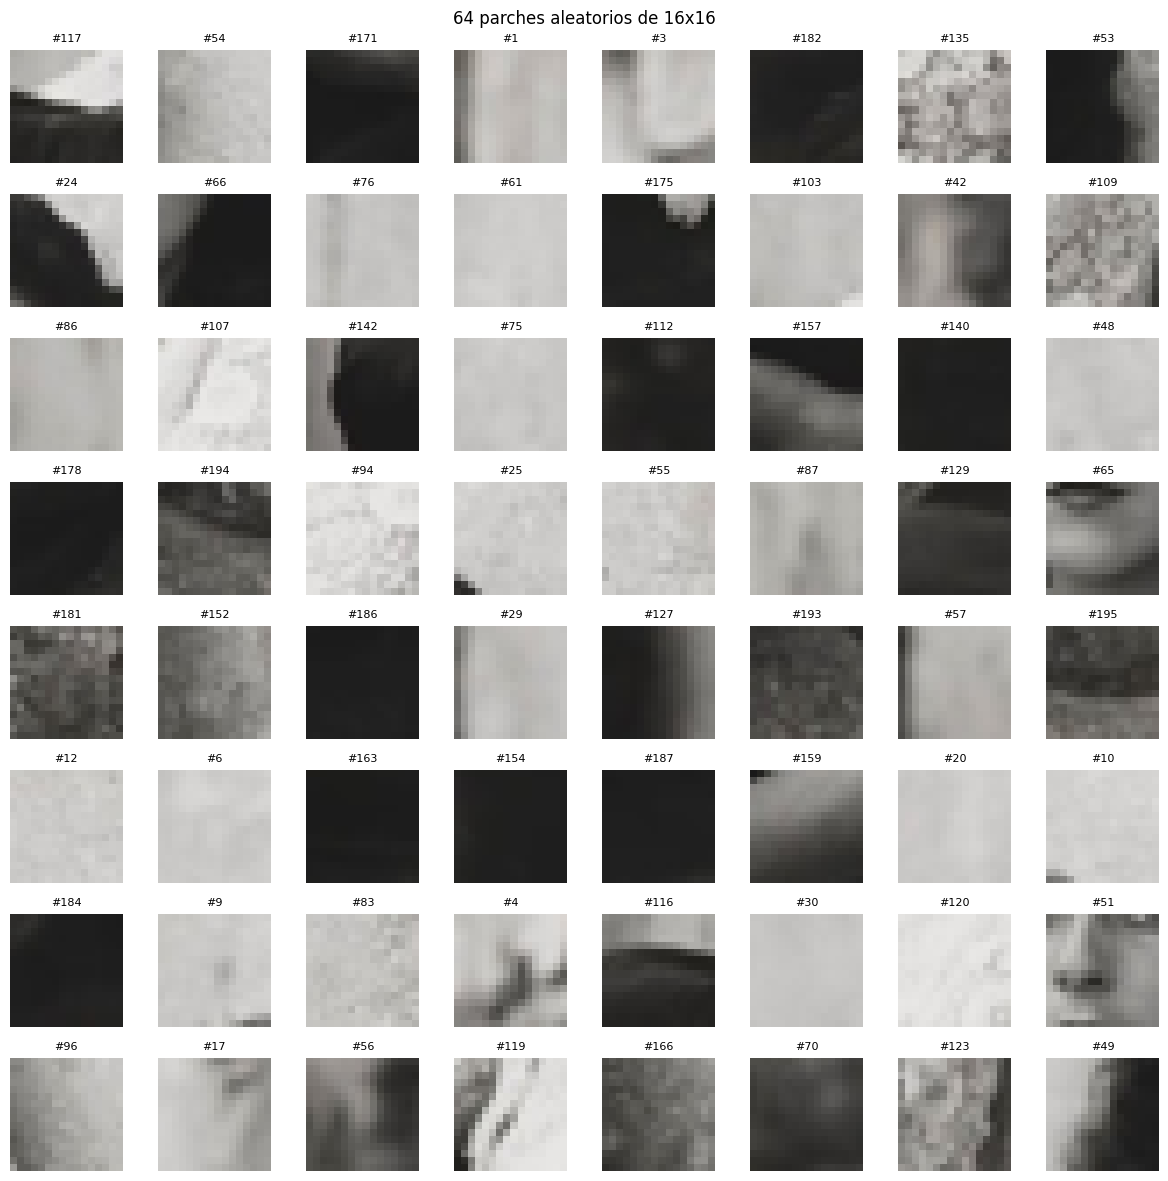

In [9]:
# Reconstruimos parches para visualizar
patches_img = x.unfold(2, P, P).unfold(3, P, P)  # (1, C, 14, 14, 16, 16)
patches_img = patches_img[0].permute(1, 2, 0, 3, 4)  # (14, 14, C, 16, 16)

# Aplanamos a lista de parches para seleccionar indices aleatorios
patches_flat = patches_img.reshape(-1, C, P, P)  # (196, C, 16, 16)
total_patches = patches_flat.shape[0]

num_mostrar = 64
num_mostrar = min(num_mostrar, total_patches)

# Muestreo aleatorio sin reemplazo (cambia en cada ejecucion)
idx_aleatorios = torch.randperm(total_patches)[:num_mostrar]

cols = 8
rows = int(np.ceil(num_mostrar / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.array(axes).reshape(rows, cols)

for k, idx in enumerate(idx_aleatorios):
    r = k // cols
    c = k % cols
    patch = patches_flat[idx].permute(1, 2, 0).numpy()
    axes[r, c].imshow(patch)
    axes[r, c].set_title(f"#{int(idx)}", fontsize=8)
    axes[r, c].axis('off')

# Oculta ejes sobrantes en la ultima fila si aplica
for k in range(num_mostrar, rows * cols):
    r = k // cols
    c = k % cols
    axes[r, c].axis('off')

plt.suptitle(f"{num_mostrar} parches aleatorios de 16x16")
plt.tight_layout()
plt.show()

## 5) De parche a embedding (token), [CLS] y posicion

En ViT, cada parche de tamano `16x16x3` se aplana a un vector y luego se proyecta a una dimension de embedding `D`.

### Que hace el token [CLS]
- Es un vector aprendible que se agrega al inicio de la secuencia.
- En self-attention, este token mezcla informacion de todos los parches.
- Al final, suele usarse como representacion global para clasificacion.

### Que hacen los positional embeddings
Un Transformer puro no conoce orden espacial por si mismo. Si permutas los parches, sin posicion explicita el modelo no sabe que es arriba o abajo.

Por eso, a cada token se le suma un embedding posicional.
Asi el modelo puede distinguir ubicaciones (arriba, abajo, izquierda, derecha).

En forma simplificada, la entrada queda asi:

`z0 = [CLS, p1, p2, ..., pN] + E_pos`

donde `p1..pN` son tokens de parches y `E_pos` codifica su posicion.

### Idea clave
- Sin posicion: el modelo ve contenido, pero pierde geometria.
- Con posicion: el embedding conserva contenido + estructura espacial.

In [12]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        patch_dim = in_channels * patch_size * patch_size
        self.proj = nn.Linear(patch_dim, embed_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B, C, H, W = x.shape
        P = self.patch_size

        patches = x.unfold(2, P, P).unfold(3, P, P)
        patches = patches.contiguous().permute(0, 2, 3, 1, 4, 5)
        patches = patches.reshape(B, -1, C * P * P)

        tokens = self.proj(patches)

        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)

        tokens = tokens + self.pos_embed
        return tokens

patch_embed = PatchEmbedding(image_size=224, patch_size=16, in_channels=3, embed_dim=128)
tokens = patch_embed(x)
print('Salida final (B, N+1, D):', tuple(tokens.shape))  # Esperado: (1, 197, 128)

Salida final (B, N+1, D): (1, 197, 128)


- Una imagen 224x224 se parte en 196 parches de 16x16.
- Cada parche se aplana y se proyecta a un embedding (token).
- Se agrega `[CLS]` y posicion.
- La secuencia resultante entra al Transformer.

Esta es la idea clave del paper **An Image is Worth 16x16 Words**.